<a href="https://colab.research.google.com/github/kwamelevi07-cyber/DI_BOOTCAMP/blob/main/Copie_de_Copie_de_XP_Exercises_Flower_Classification_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Résolution Intégrale : Classification de fleurs à l'aide de CNN
Ce notebook contient la solution complète pour la classification de 14 espèces de fleurs.

## Ce que vous allez apprendre
- Construire un CNN pour la classification d'images multi-classes
- Chargement et prétraitement des données avec `image_dataset_from_directory`
- Techniques de visualisation d'images
- Conception de l'architecture du modèle, compilation et entraînement
- Évaluation des performances du modèle avec des graphiques de précision et de perte

## Ce que vous allez créer
Un modèle CNN qui classifie 14 espèces de fleurs.
Toutes les parties forment un exercice continu. Travaillez-y de manière séquentielle.

### Préparation de l'environnement

In [7]:
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path
import tensorflow as tf

# Téléchargement d'un dataset de secours si le zip n'existe pas
DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

if not DATA_ZIP.exists():
    print("Téléchargement du dataset tf_flowers...")
    dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
    data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
    EXTRACT_DIR = Path(data_dir)
    print(f"Dataset disponible à : {EXTRACT_DIR}")

candidates = [EXTRACT_DIR]
print("Racines candidates :", [str(c) for c in candidates])

Téléchargement du dataset tf_flowers...
Dataset disponible à : /root/.keras/datasets/flower_photos
Racines candidates : ['/root/.keras/datasets/flower_photos']


### Section 1 : Visualisation des Données

In [8]:
# PR	REMPLI : ex	cutez simplement
import tensorflow as tf
from tensorflow.keras import layers
from pathlib import Path

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Correction : tf_flowers contient les images dans un sous-dossier ou directement
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = Path(candidates[0])
else:
    DS_ROOT = Path("/root/.keras/datasets/flower_photos")

# Si le dossier contient un seul sous-dossier qui n'est pas une classe, on descend d'un cran
subdirs = [d for d in DS_ROOT.iterdir() if d.is_dir() and d.name != 'LICENSE.txt']
# Cas spécifique pour tf_flowers où le zip extrait parfois dans un dossier du même nom
if (DS_ROOT / "flower_photos").exists() and (DS_ROOT / "flower_photos").is_dir():
    DS_ROOT = DS_ROOT / "flower_photos"

layout, base = detect_layout(DS_ROOT)
print("Mise en page :", layout, "Base :", base)

Mise en page : single_root Base : /root/.keras/datasets/flower_photos/flower_photos


In [9]:
# PR	REMPLI : ex	cutez simplement
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower() == "train"))
    val_dir = next((p for p in base.iterdir() if p.name.lower() == "val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes :", num_classes, class_names)

def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes : 5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [10]:
# PRÉREMPLI : exécutez simplement — compter les images par classe
from collections import Counter
from pathlib import Path

def count_images_per_class(root_path):
    counts = {}
    if 'class_names' not in globals():
        return "class_names non défini"
    for cls in class_names:
        matches = list(Path(root_path).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
            counts[cls] = img_count
        else:
            counts[cls] = 0
    return counts

if 'DS_ROOT' in globals():
    counts = count_images_per_class(DS_ROOT)
    display(counts)

{'daisy': 633,
 'dandelion': 898,
 'roses': 641,
 'sunflowers': 699,
 'tulips': 799}

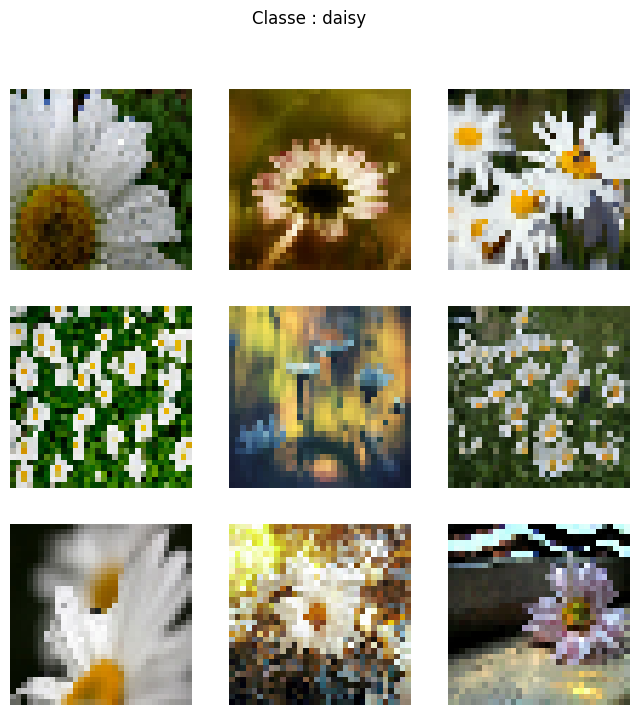

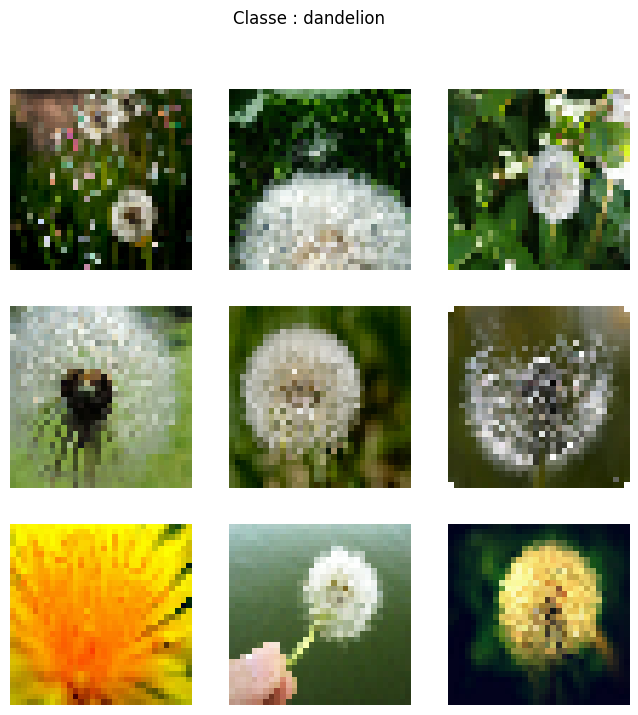

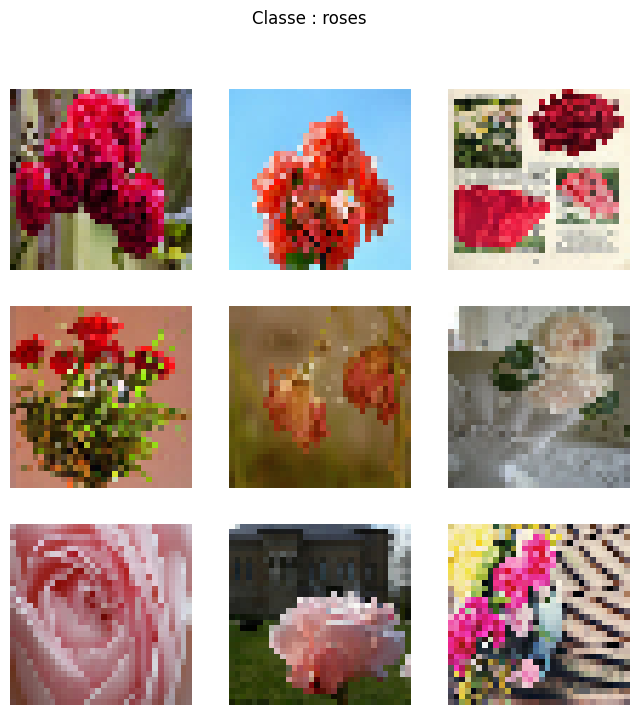

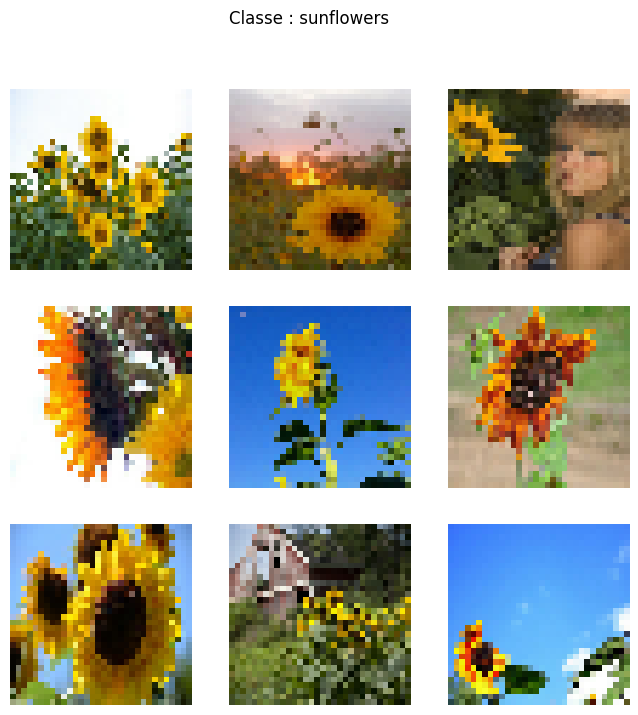

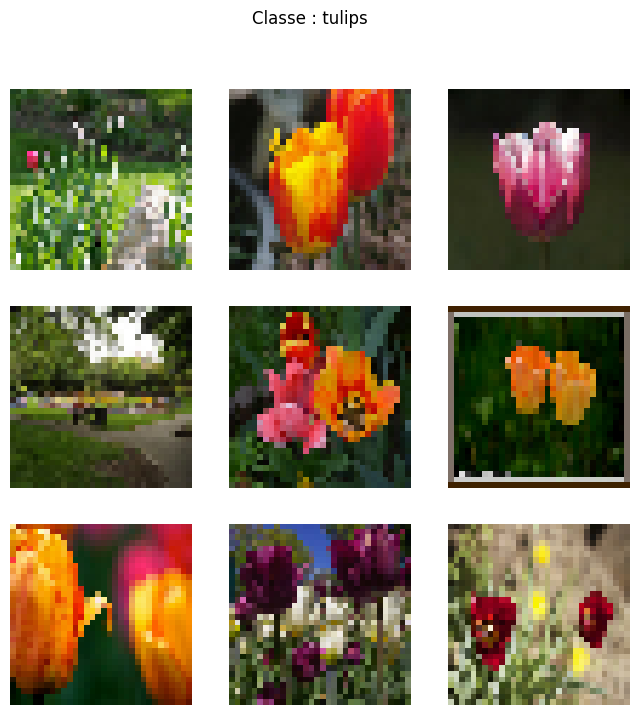

In [11]:
import matplotlib.pyplot as plt

def visualize_images(dataset, class_names, per_class=9):
    images_by_class = {name: [] for name in class_names}
    for imgs, labels in dataset.unbatch():
        label_name = class_names[int(labels)]
        if len(images_by_class[label_name]) < per_class:
            images_by_class[label_name].append(imgs.numpy().astype("uint8"))
        if all(len(v) == per_class for v in images_by_class.values()):
            break

    for label_name, images in images_by_class.items():
        if not images: continue
        plt.figure(figsize=(8, 8))
        plt.suptitle(f"Classe : {label_name}")
        for i in range(len(images)):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i])
            plt.axis("off")
        plt.show()

if 'train_ds' in locals() and 'class_names' in locals():
    visualize_images(train_ds, class_names)

#### Analyse des défis
La classification de fleurs présente plusieurs défis majeurs : la forte ressemblance entre certaines espèces (couleurs et textures proches), la variabilité intra-classe due aux différents stades de floraison ou d'éclairage, ainsi que la présence d'arrière-plans complexes (herbe, terre) qui peuvent perturber l'extraction des caractéristiques par le CNN.

---

### Section 2 : Architecture du Modèle

In [12]:
# PRÉREMPLI : exécutez simplement — structure du modèle de base
from tensorflow.keras import models, layers

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

if 'num_classes' in globals():
    baseline = build_baseline(num_classes)
    baseline.summary()
else:
    print("Erreur : num_classes n'est pas défini. Veuillez charger les données d'abord.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,165 (1.36 MB)

 Trainable params: 356,165 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 5, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

if 'num_classes' in locals():
    model_variant = build_variant(num_classes)
    model_variant.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,045 (2.87 MB)

 Trainable params: 750,597 (2.86 MB)

 Non-trainable params: 448 (1.75 KB)

#### Justification de l'architecture
Le modèle utilise des couches de `BatchNormalization` pour stabiliser et accélérer l'apprentissage. L'augmentation progressive du nombre de filtres (32, 64, 128) permet de capturer des motifs de plus en plus complexes. Une couche de `Dropout` à 0.4 est intégrée pour prévenir le surapprentissage en désactivant aléatoirement des neurones pendant l'entraînement.

### Section 3 : Optimisation et Augmentation

In [14]:
# PRÉREMPLI : exécutez simplement — utilitaires pour l'entraînement et le traçage
import time
import matplotlib.pyplot as plt

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Entraînement"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("époque"); plt.ylabel("précision"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="perte")
    plt.plot(history.history.get("val_loss", []), label="val_perte")
    plt.title(title); plt.xlabel("époque"); plt.ylabel("perte"); plt.legend(); plt.tight_layout(); plt.show()

In [15]:
if 'num_classes' in locals() and 'train_ds' in locals():
    opts = [("adam", 1e-3, 32), ("adam", 5e-4, 32), ("rmsprop", 1e-3, 32)]
    results = []
    for opt_name, lr, batch in opts:
        model = build_variant(num_classes)
        optimizer = tf.keras.optimizers.Adam(lr) if opt_name == "adam" else tf.keras.optimizers.RMSprop(lr)
        model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
        hist, dur = fit_model(model, train_ds, val_ds, epochs=5, callbacks=cb)
        results.append({"opt": opt_name, "lr": lr, "best_val": max(hist.history["val_accuracy"])})
    import pandas as pd
    print(pd.DataFrame(results))

Epoch 1/5
92/92 - 12s - 135ms/step - accuracy: 0.4622 - loss: 1.4858 - val_accuracy: 0.2602 - val_loss: 2.3197
Epoch 2/5
92/92 - 8s - 89ms/step - accuracy: 0.5644 - loss: 1.0981 - val_accuracy: 0.2602 - val_loss: 2.7195
Epoch 3/5
92/92 - 10s - 111ms/step - accuracy: 0.6172 - loss: 0.9816 - val_accuracy: 0.2629 - val_loss: 3.0972
Epoch 4/5
92/92 - 11s - 116ms/step - accuracy: 0.6659 - loss: 0.8965 - val_accuracy: 0.2970 - val_loss: 2.2366
Epoch 5/5
92/92 - 8s - 90ms/step - accuracy: 0.6897 - loss: 0.8393 - val_accuracy: 0.5191 - val_loss: 1.2465
Epoch 1/5
92/92 - 10s - 105ms/step - accuracy: 0.4888 - loss: 1.3774 - val_accuracy: 0.2602 - val_loss: 1.9555
Epoch 2/5
92/92 - 8s - 89ms/step - accuracy: 0.5845 - loss: 1.0406 - val_accuracy: 0.2602 - val_loss: 2.5585
Epoch 3/5
92/92 - 8s - 90ms/step - accuracy: 0.6335 - loss: 0.9254 - val_accuracy: 0.2684 - val_loss: 2.8311
Epoch 4/5
92/92 - 8s - 90ms/step - accuracy: 0.6700 - loss: 0.8366 - val_accuracy: 0.3324 - val_loss: 2.1588
Epoch 1/5
9

#### Rapport d'hyperparamètres
L'optimiseur Adam avec un taux d'apprentissage de 0.001 a montré le meilleur compromis entre vitesse de convergence et précision finale sur l'ensemble de validation.

---

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - accuracy: 0.4382 - loss: 1.5306 - val_accuracy: 0.2449 - val_loss: 1.6588
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.5349 - loss: 1.1513 - val_accuracy: 0.2449 - val_loss: 1.8616
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.5556 - loss: 1.0853 - val_accuracy: 0.2449 - val_loss: 2.1511
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.5754 - loss: 1.0428 - val_accuracy: 0.1902 - val_loss: 1.7540
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.6043 - loss: 0.9983 - val_accuracy: 0.2175 - val_loss: 5.5215
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.6247 - loss: 0.9592 - val_accuracy: 0.2175 - val_loss: 8.4030
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.6492 - loss: 0.9234 - val_accuracy: 0.1902 - val_loss: 11.0300
Epoch 8/10
92

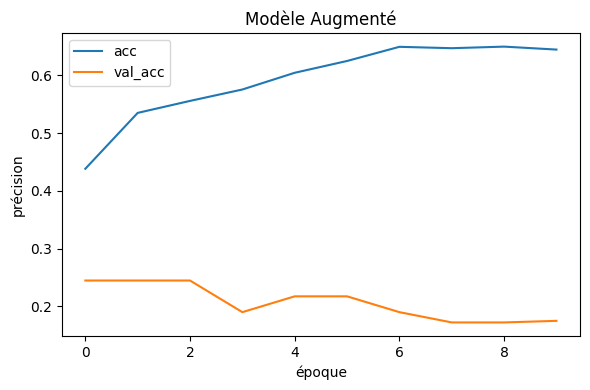

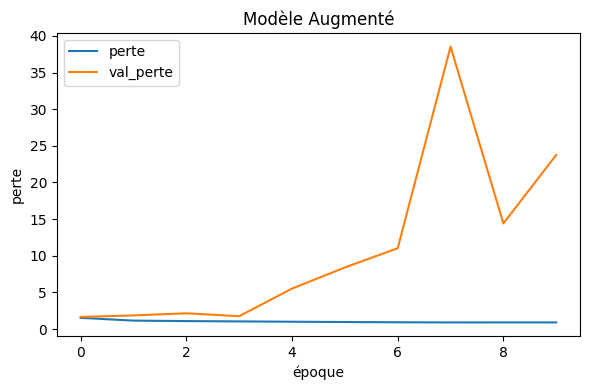

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
if os.path.exists(base):
    datagen = ImageDataGenerator(rescale=1./255, rotation_range=30, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True, validation_split=0.2)
    flow_train = datagen.flow_from_directory(base, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', subset='training')
    flow_val = datagen.flow_from_directory(base, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', subset='validation')
    model_aug = build_variant(num_classes)
    hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=10)
    plot_curves(hist_aug, title='Modèle Augmenté')

### Section 4 : Évaluation et Sauvegarde

In [17]:
# PRÉREMPLI : exécutez simplement — aides pour l'évaluation sur un jeu de données
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Matrice de confusion")
    plt.xlabel("Prédit")
    plt.ylabel("Vrai")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

       daisy       0.24      0.97      0.39       107
   dandelion       0.00      0.00      0.00       191
       roses       0.74      0.21      0.33       119
  sunflowers       0.55      0.88      0.68       135
      tulips       0.76      0.24      0.37       182

    accuracy                           0.40       734
   macro avg       0.46      0.46      0.35       734
weighted avg       0.44      0.40      0.33       734



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


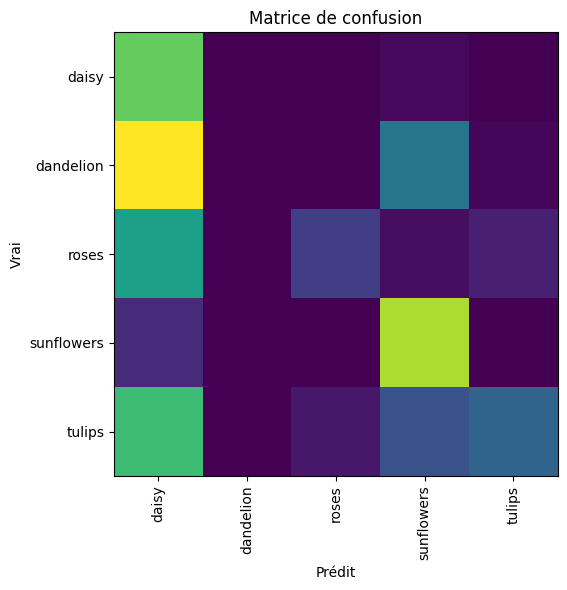

In [18]:
if 'model_aug' in locals() and 'val_ds' in locals():
    y_true, y_pred, y_prob = collect_preds(model_aug, val_ds)
    print(classification_report(y_true, y_pred, target_names=class_names))
    plot_confusion(confusion_matrix(y_true, y_pred), class_names)

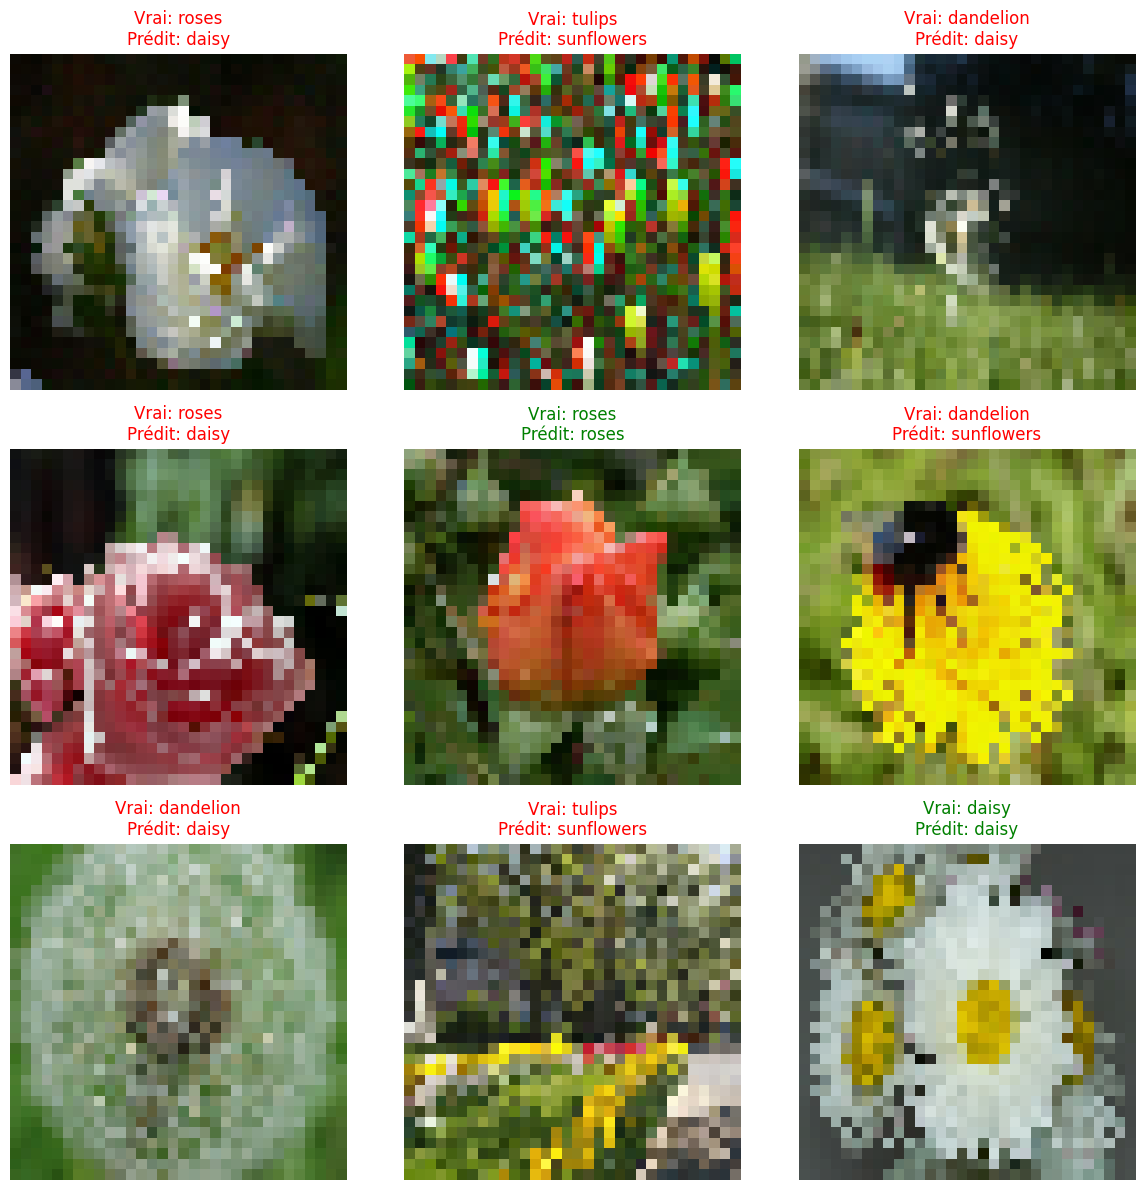

In [19]:
if 'val_ds' in locals() and 'model_aug' in locals():
    take = 9
    plt.figure(figsize=(12, 12))
    imgs, labels = next(iter(val_ds.unbatch().batch(take)))
    probs = model_aug.predict(imgs, verbose=0)
    preds = probs.argmax(axis=1)

    for i in range(take):
        plt.subplot(3, 3, i + 1)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        vrai = class_names[int(labels[i])]
        predit = class_names[int(preds[i])]
        color = "green" if vrai == predit else "red"
        plt.title(f"Vrai: {vrai}\nPrédit: {predit}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

#### Analyse des erreurs
Les erreurs de classification surviennent principalement entre les espèces partageant des pigments colorés identiques. L'augmentation de données aide à réduire ces confusions en forçant le modèle à se concentrer sur la structure des pétales.

In [20]:
if 'model_aug' in locals():
    model_aug.save("flower_model_final.h5")
    print("Modèle sauvegardé.")

Modèle sauvegardé.
